# Лабораторная работа 4. Кластеризация

## Цель работы:
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качества.

## Датасет
**Источник:** [Flower Classification](https://www.kaggle.com/datasets/tusharkute/flower-classification)

## Описание
Этот набор данных представляет собой синтетическую коллекцию из 50 записей, разработанную для практики и изучения многоклассовой классификации. Он посвящен четырем распространённым типам цветов: роза, жасмин, бархатцы и гибискус. Данные содержат количественные морфологические и цветовые признаки, которые можно использовать для различения этих видов. 

**Основные характеристики:**
- Подходит для обучения - изучения основ классификации и кластеризации
- Объем данных: 50 наблюдений
- Количество признаков: 11


## Описание переменных датасета

| Переменная                  | Описание                                                                  |
| --------------------------- | ------------------------------------------------------------------------- |
| **ID**                      | Уникальный идентификатор для каждой записи о цветке                       |
| **Flower Type**             | Тип цветка (Rose, Jasmine, Marigold, Hibiscus)                            |
| **Sepal Length (cm)**       | Длина чашелистика в сантиметрах                                           |
| **Petal Length (cm)**       | Длина лепестка в сантиметрах                                              |
| **Sepal Width (cm)**        | Ширина чашелистика в сантиметрах                                          |
| **Petal Width (cm)**        | Ширина лепестка в сантиметрах                                             |
| **Flower Radius (cm)**      | Радиус цветка в сантиметрах                                               |
| **Number of Petals/Sepals** | Количество лепестков или чашелистиков (в зависимости от структуры цветка) |
| **Avg_R**                   | Среднее значение красного канала (0–255) для доминирующего цвета          |
| **Avg_G**                   | Среднее значение зелёного канала (0–255) для доминирующего цвета          |
| **Avg_B**                   | Среднее значение синего канала (0–255) для доминирующего цвета            |


In [208]:
#python -m pip install matplotlib pandas scikit-learn seaborn jupyter numpy ipykernel
 

In [2]:
# # Импорт библиотек
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import skew, kurtosis, kstest


## 1. Подготовка данных: первичный анализ

In [254]:
# Чтение данных из файла в датафрейм. Настройки
path = 'flower-classification.csv'
#target = 'DEATH_EVENT'

# Дескриптивный анализ столбцов
pd.set_option('display.float_format', '{:.2f}'.format)
df = pd.read_csv(path)
df.info()
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       50 non-null     int64  
 1   Flower Type              50 non-null     object 
 2   Sepal Length (cm)        50 non-null     float64
 3   Petal Length (cm)        50 non-null     float64
 4   Sepal Width (cm)         50 non-null     float64
 5   Petal Width (cm)         50 non-null     float64
 6   Flower Radius (cm)       50 non-null     float64
 7   Number of Petals/Sepals  50 non-null     int64  
 8   Avg_R                    50 non-null     int64  
 9   Avg_G                    50 non-null     int64  
 10  Avg_B                    50 non-null     int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 4.4+ KB
         ID  Sepal Length (cm)  Petal Length (cm)  Sepal Width (cm)  \
count 50.00              50.00              50.00             

#### Переменные ID и Flower Type можно удалить, т.к. в задаче кластеризации они не имеют смысл. Предполагается, что предварительно нас не интересует количество и принадлежность к какому-либо классу

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sepal Length (cm)        50 non-null     float64
 1   Petal Length (cm)        50 non-null     float64
 2   Sepal Width (cm)         50 non-null     float64
 3   Petal Width (cm)         50 non-null     float64
 4   Flower Radius (cm)       50 non-null     float64
 5   Number of Petals/Sepals  50 non-null     int64  
 6   Avg_R                    50 non-null     int64  
 7   Avg_G                    50 non-null     int64  
 8   Avg_B                    50 non-null     int64  
dtypes: float64(5), int64(4)
memory usage: 3.6 KB


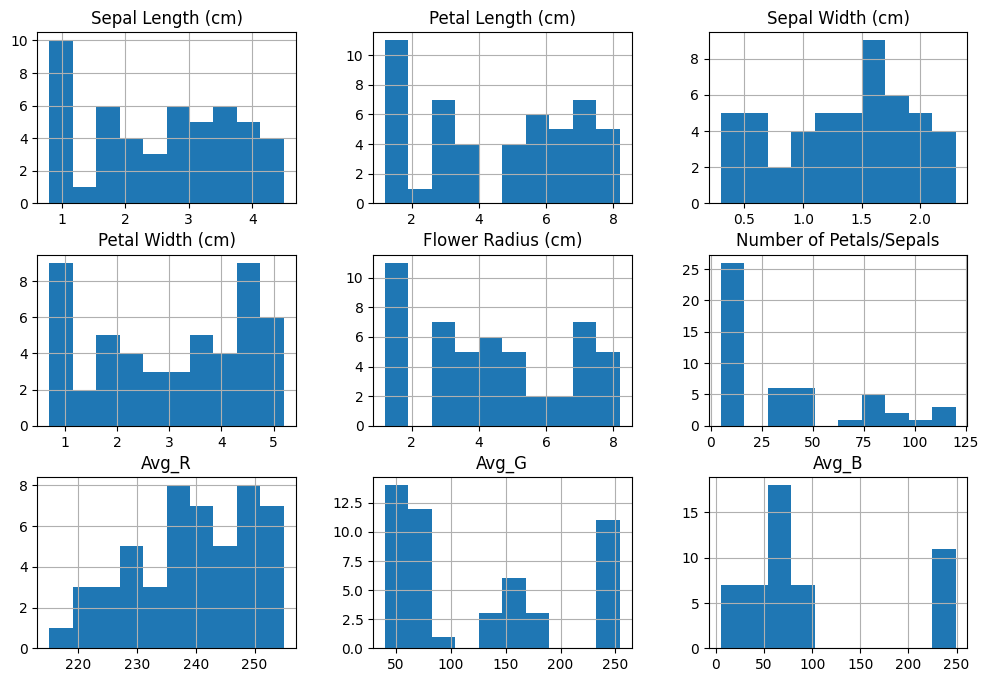

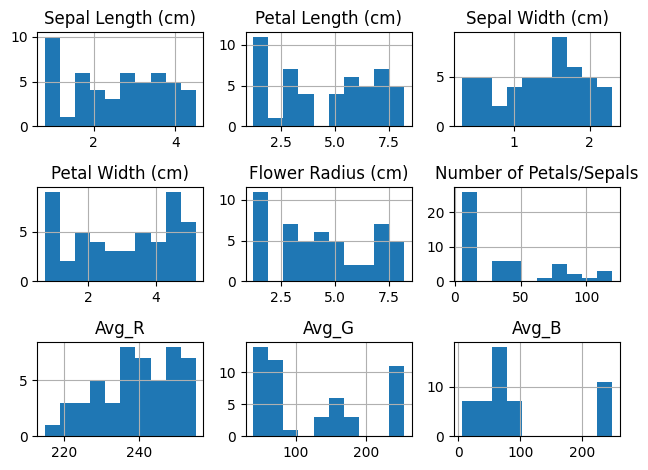

In [255]:
# Визуализация признаков и целевой переменной

#df['Sex'] = df['Gender_Code'].map({'Male': 0, 'Female': 1})
#df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})
# df['CAECn'] = df['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always' : 3})
# df['CALCn'] = df['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always' : 3})
# df['MTRANSn'] = df['MTRANS'].map({'Walking': 0, 'Bike': 1, 'Motorbike': 2, 'Public_Transportation' : 3})
# df = df.replace({'yes': 1, 'no': 0})

#df['Sex'] = df['gender'].map({'Male': 0, 'Female': 1})
drop_columns = ['Gender', 'CAEC', 'CALC', 'Obesity', 'MTRANS',  'assignments_submitted', 'name', 'gender', 'student_id', 'total_assignments', 'total_lectures', 'total_lab_sessions',  
                'Date', 'cluster', 'city_name', 'country', 'ID', 'Flower Type', 'key', 'name', 'image', 'splash', 'criticalStrikeChance','criticalStrikeChancePerLevel',
                 'InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'CustomerID', 'Country', 'id', 'Flower Type'
                ] # Ненужные столбцы


#df['region_encoded'], uniques = pd.factorize(df['Region'])

y_true, uniques = pd.factorize(df['Flower Type'])

df.drop(drop_columns, axis=1, errors='ignore', inplace=True)


df = df.dropna()

numeric_features = [col for col in df.select_dtypes(include=[np.number]).columns.tolist()]
df = df[numeric_features]

df.info()
df.hist(figsize=(12,8))
df.hist()
plt.tight_layout()
plt.show()

#### После первичного анализа были удалены лишние переменные. Оставлены только переменные числового типа для дальнейшего анализа и решения задачи кластеризации


## 2. Визуальный анализ: построение гистограмм, проверка на нормальность

Sepal Length (cm)
Ассиметрия: -0.095
Эксцесс: -1.238
K-S p-value: 0.564
K-S статистика: 0.108
Нормальность: Да
α = 0.05



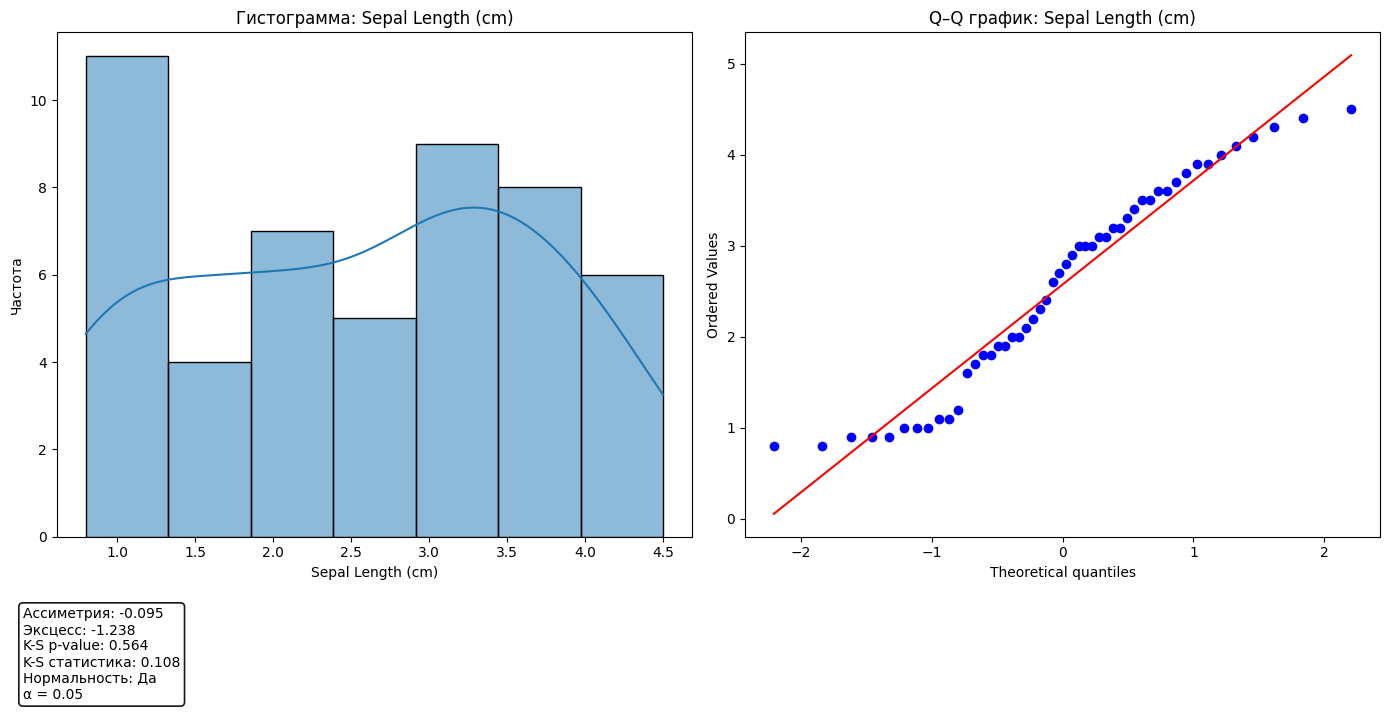

Petal Length (cm)
Ассиметрия: -0.080
Эксцесс: -1.460
K-S p-value: 0.479
K-S статистика: 0.116
Нормальность: Да
α = 0.05



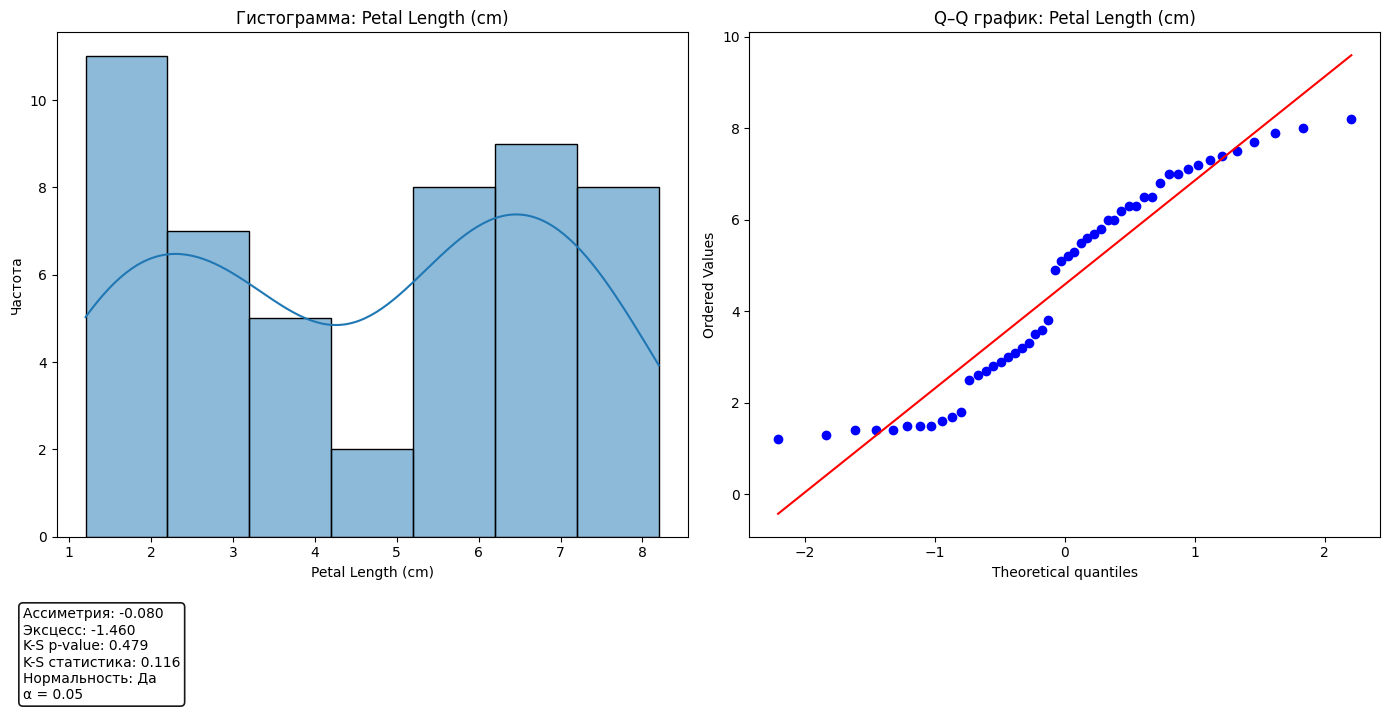

Sepal Width (cm)
Ассиметрия: -0.268
Эксцесс: -0.990
K-S p-value: 0.442
K-S статистика: 0.119
Нормальность: Да
α = 0.05



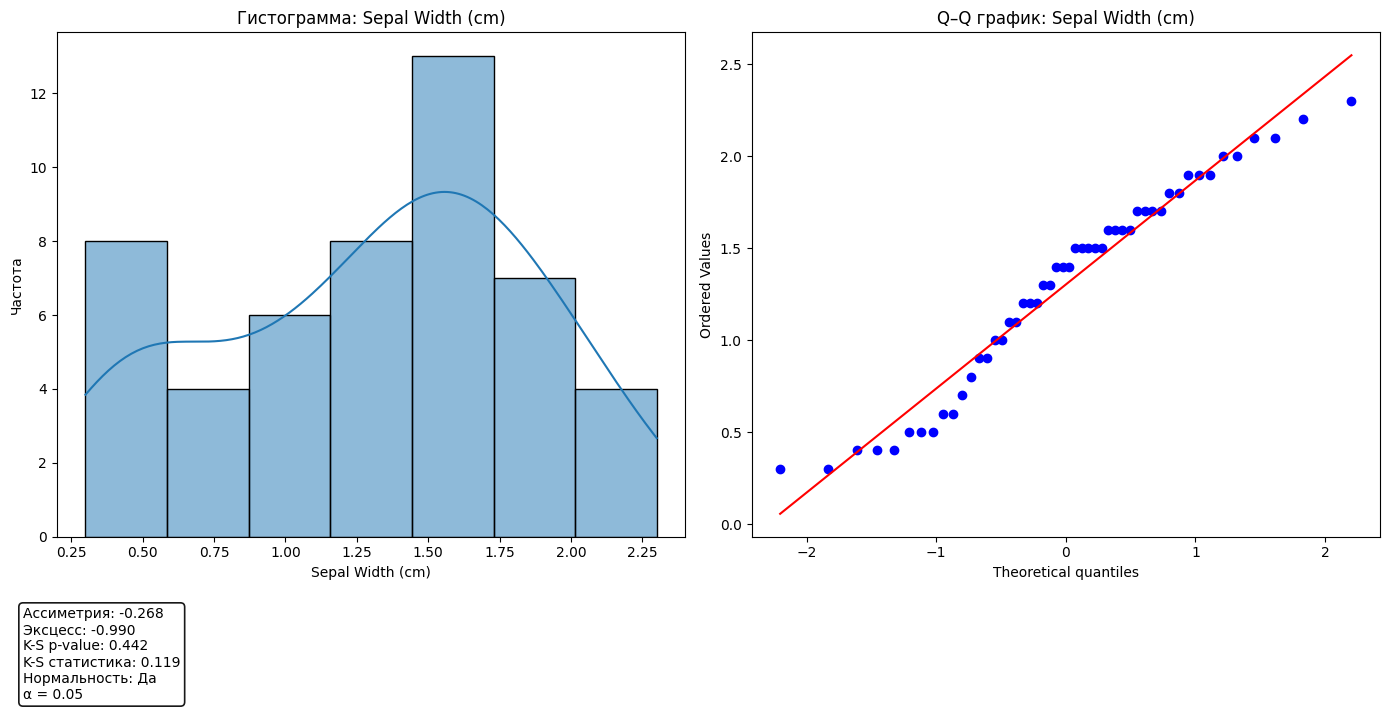

Petal Width (cm)
Ассиметрия: -0.199
Эксцесс: -1.426
K-S p-value: 0.366
K-S статистика: 0.127
Нормальность: Да
α = 0.05



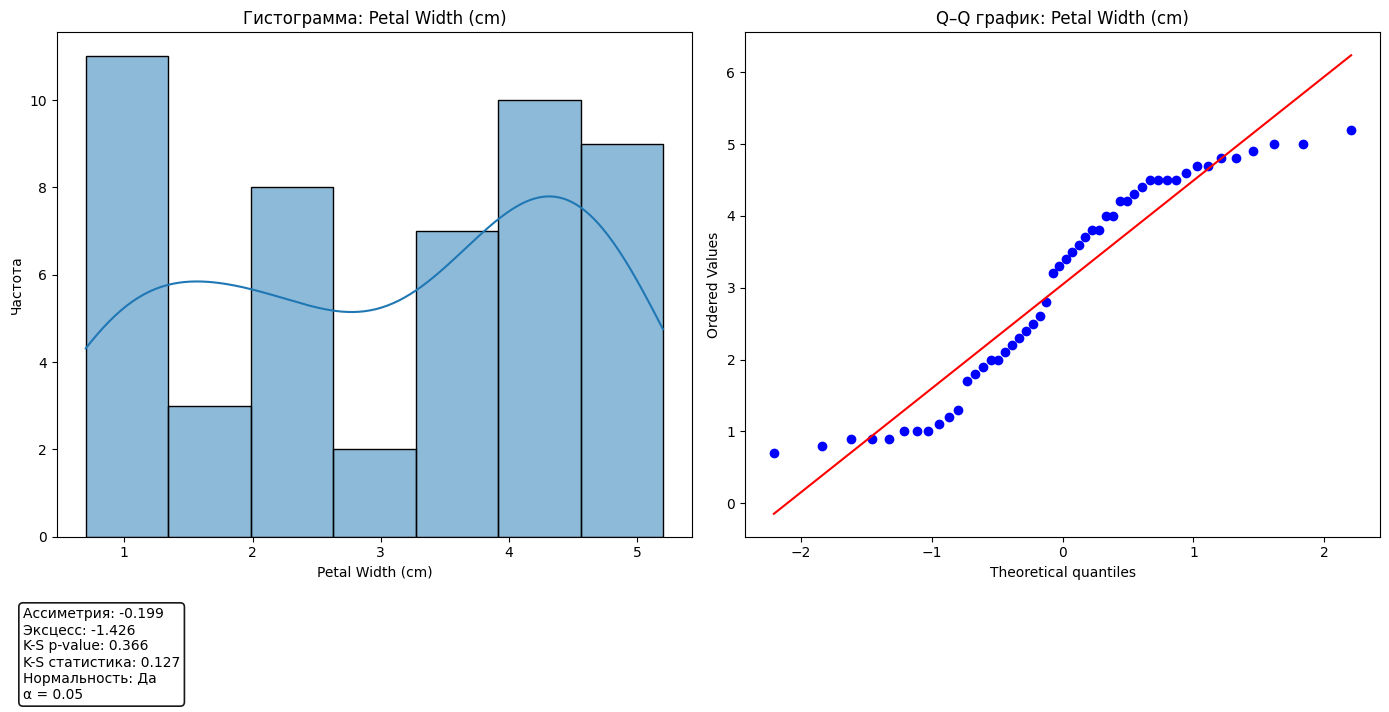

Flower Radius (cm)
Ассиметрия: 0.145
Эксцесс: -1.222
K-S p-value: 0.610
K-S статистика: 0.104
Нормальность: Да
α = 0.05



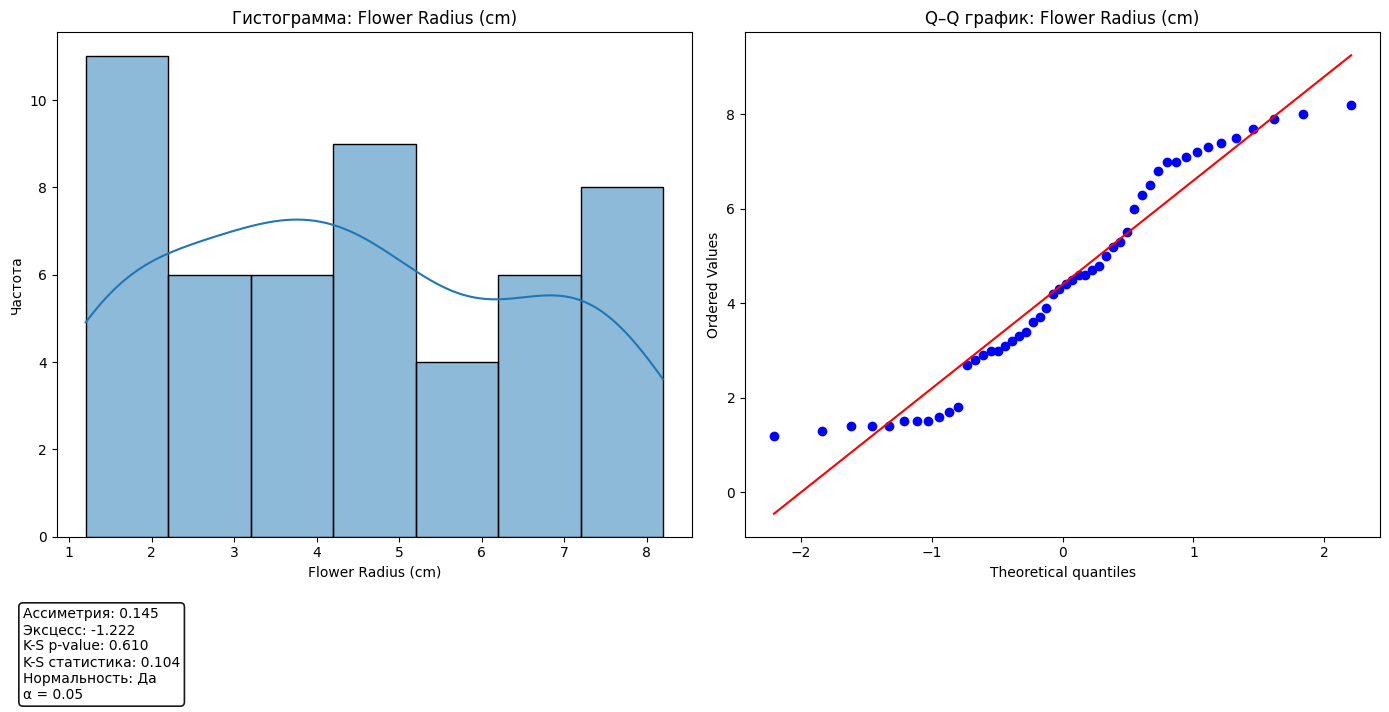

Number of Petals/Sepals
Ассиметрия: 0.911
Эксцесс: -0.503
K-S p-value: 0.000
K-S статистика: 0.289
Нормальность: Нет
α = 0.05



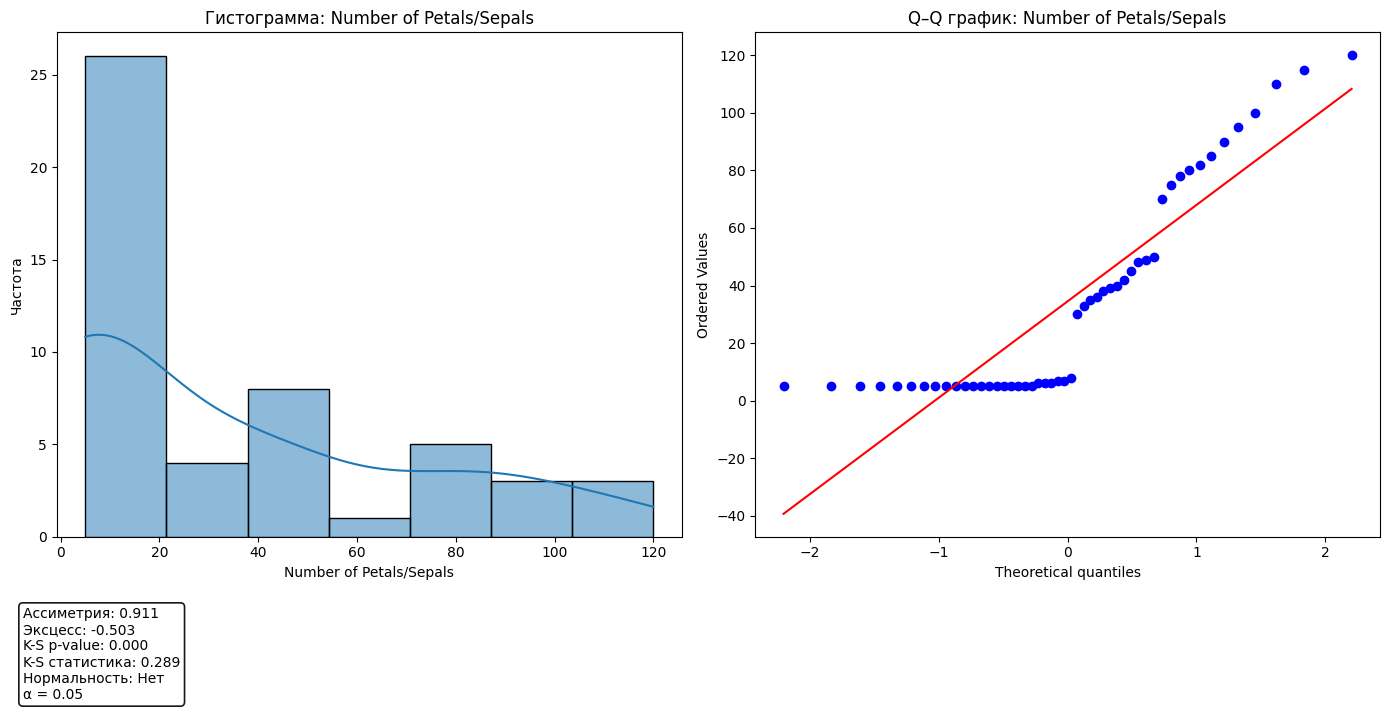

Avg_R
Ассиметрия: -0.355
Эксцесс: -0.696
K-S p-value: 0.724
K-S статистика: 0.095
Нормальность: Да
α = 0.05



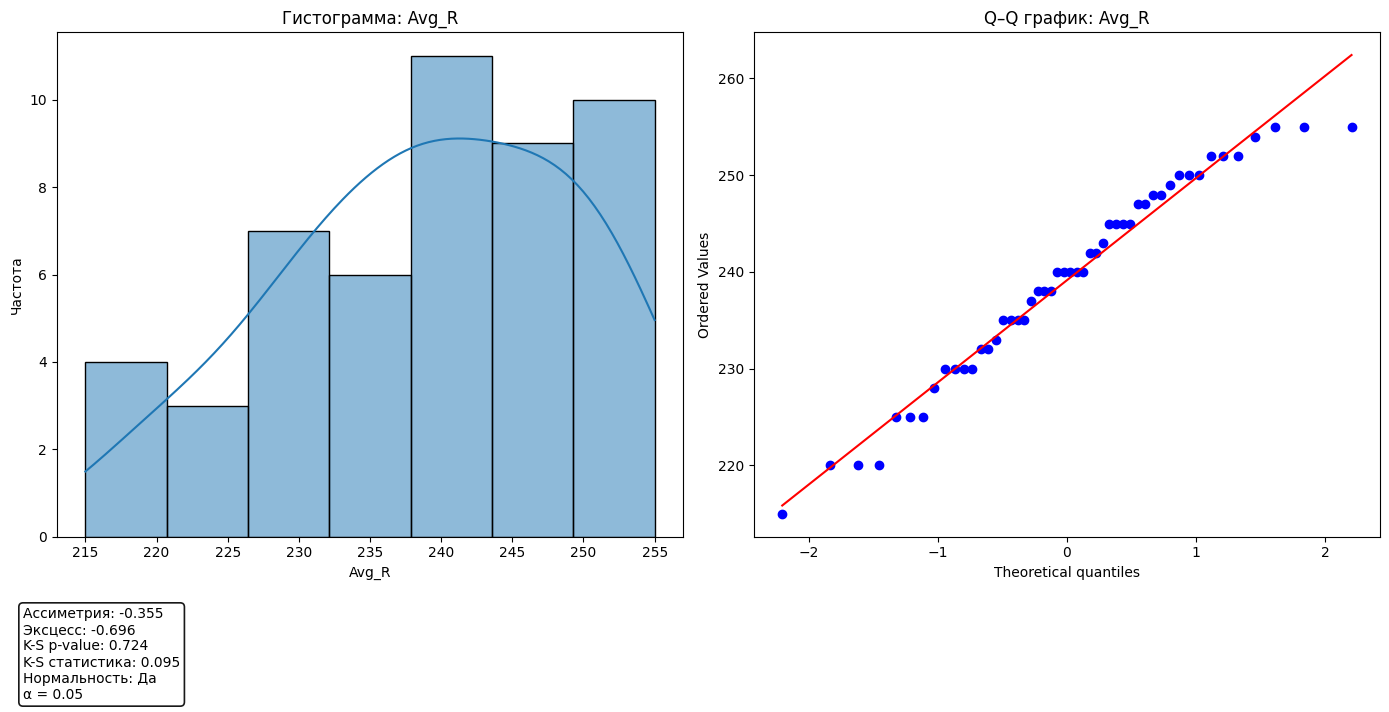

Avg_G
Ассиметрия: 0.569
Эксцесс: -1.233
K-S p-value: 0.005
K-S статистика: 0.240
Нормальность: Нет
α = 0.05



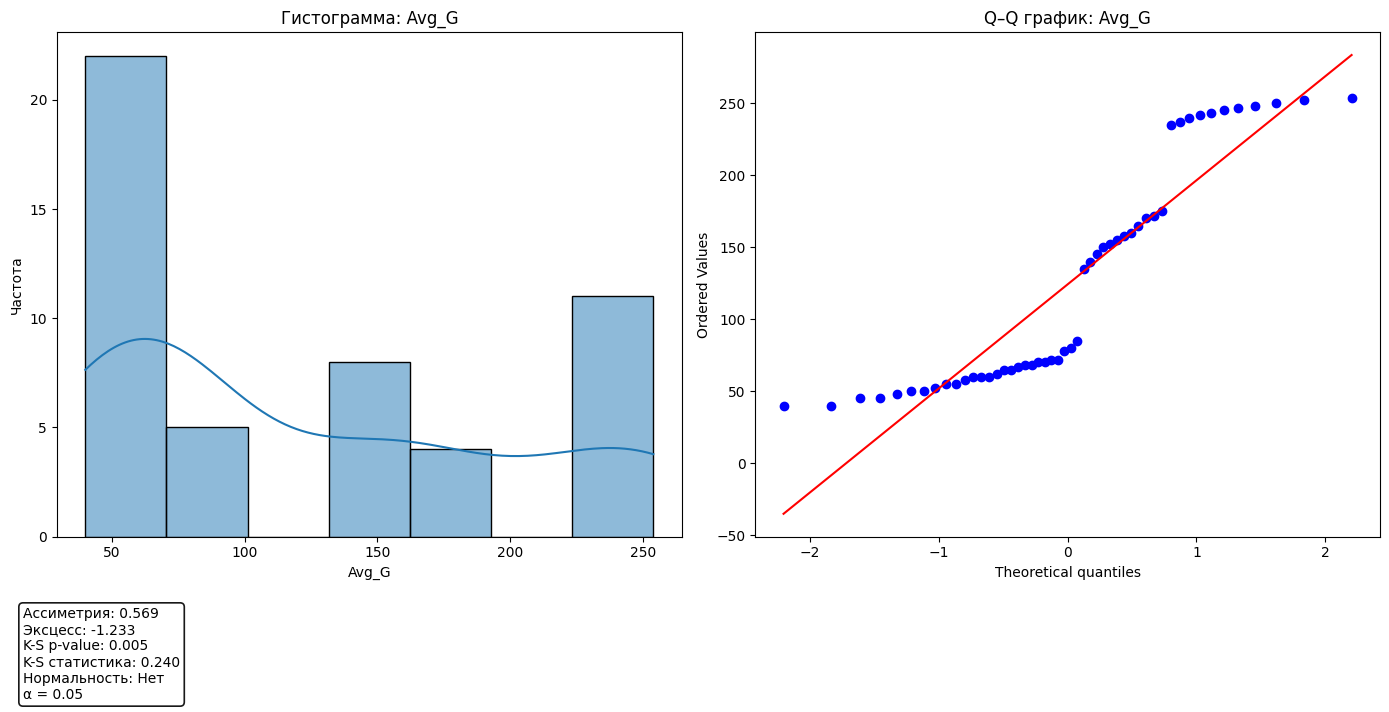

Avg_B
Ассиметрия: 1.094
Эксцесс: -0.391
K-S p-value: 0.000
K-S статистика: 0.297
Нормальность: Нет
α = 0.05



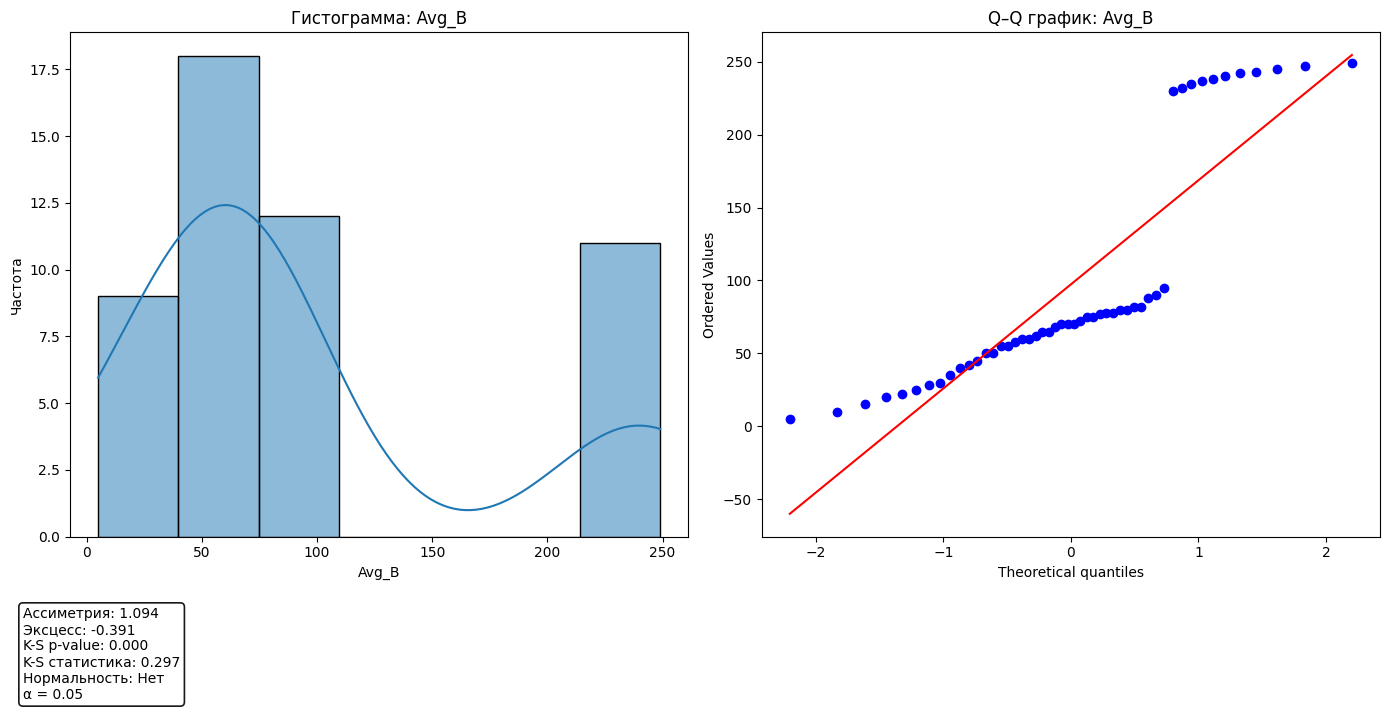

In [256]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from scipy.stats import skew, kurtosis, kstest, probplot

ALPHA = 0.05

for _, column in enumerate(df.columns):

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- Гистограмма ---
    sb.histplot(df[column], kde=True, bins='sturges', ax=axes[0])
    axes[0].set_title(f'Гистограмма: {column}')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Частота')

    # --- Q–Q график ---
    probplot(df[column], dist='norm', plot=axes[1])
    axes[1].set_title(f'Q–Q график: {column}')

    # --- Статистика Колмогорова-Смирнова ---
    ks_stat, ks_p_value = kstest(df[column], 'norm', args=(np.mean(df[column]), np.std(df[column])))

    legend = (
        f'Ассиметрия: {skew(df[column]):.3f}\n'
        f'Эксцесс: {kurtosis(df[column]):.3f}\n'
        f'K-S p-value: {ks_p_value:.3f}\n'
        f'K-S статистика: {ks_stat:.3f}\n'
        f'Нормальность: {'Да' if ks_p_value >= ALPHA else 'Нет'}\n'
        f'α = {ALPHA}'
    )

    # Текст под графиками
    fig.text(
        0.02, -0.02, legend,
        ha='left', va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round', facecolor='white',
            edgecolor='black', linewidth=1.2, alpha=0.9
        )
    )

    print(column)
    print('=' * 50)
    print(legend)
    print('=' * 50 + '\n')

    plt.tight_layout()
    plt.show()


Следующие переменные имеют минимальное отколонение от нормального распределения:
- Sepal Length (cm)

- Petal Length (cm)

- Sepal Width (cm)

- Petal Width (cm)

- Flower Radius (cm)

- Avg_R

Распределение остальных переменных не является нормальным:
- Number of Petals/Sepals

- Avg_G

- Avg_B

Такой результат вероятно обусловлен малым размером выборки и синтетической природой исходных данных.

## 3. Проверка корреляции между переменными. Составление матрицы корреляций


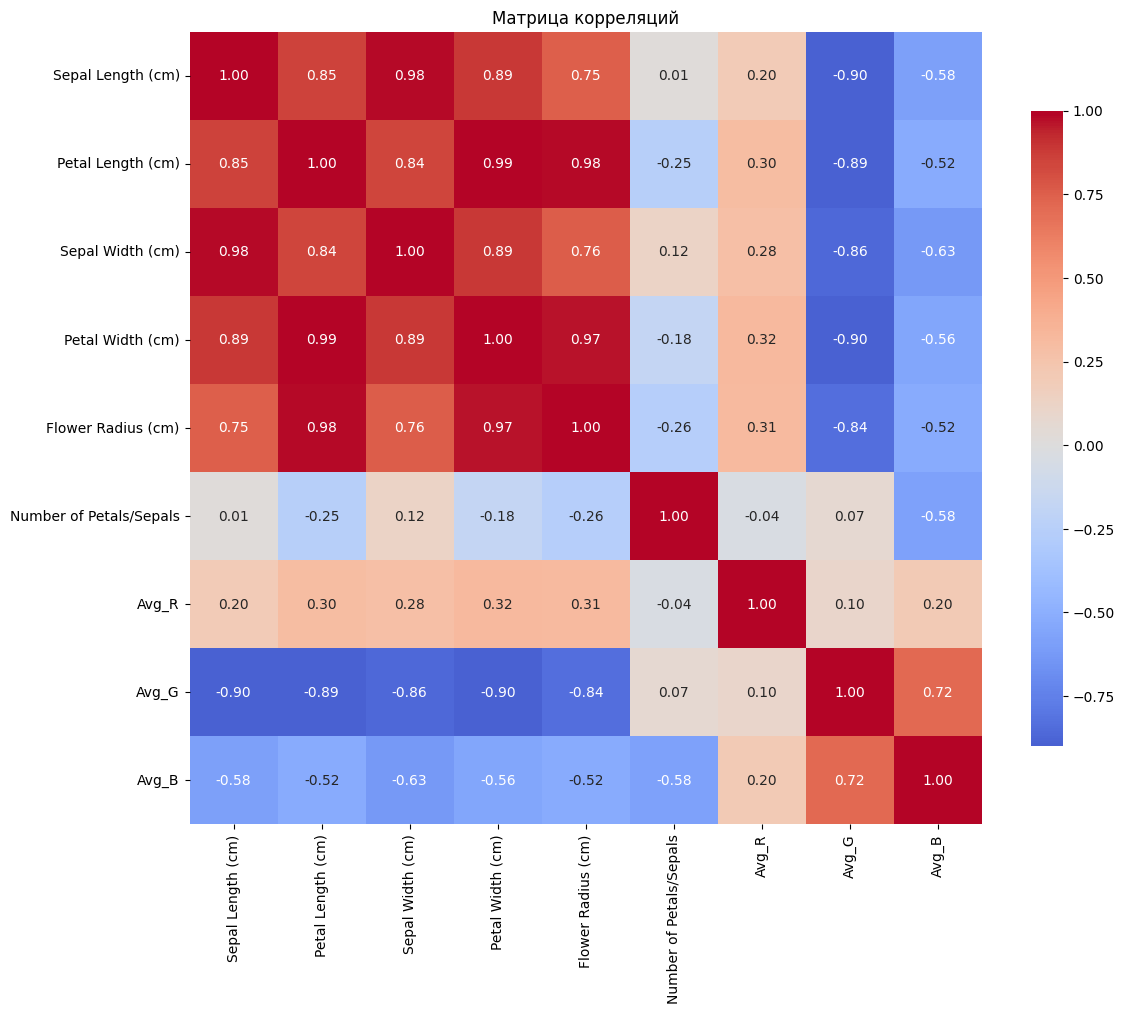

Коэффициенты корреляции для целевой переменной:
                          Sepal Length (cm)  Petal Length (cm)  \
Sepal Length (cm)                     1.00               0.85   
Petal Length (cm)                     0.85               1.00   
Sepal Width (cm)                      0.98               0.84   
Petal Width (cm)                      0.89               0.99   
Flower Radius (cm)                    0.75               0.98   
Number of Petals/Sepals               0.01              -0.25   
Avg_R                                 0.20               0.30   
Avg_G                                -0.90              -0.89   
Avg_B                                -0.58              -0.52   

                         Sepal Width (cm)  Petal Width (cm)  \
Sepal Length (cm)                    0.98              0.89   
Petal Length (cm)                    0.84              0.99   
Sepal Width (cm)                     1.00              0.89   
Petal Width (cm)                     0.89       

In [257]:
# Составление матрицы корреляций и тепловой карты
correlation_matrix = df.corr(method='pearson')

plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': .8})

plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

#correlation_val = correlation_matrix[target].sort_values(ascending=False)
print('Коэффициенты корреляции для целевой переменной:\n',correlation_matrix)

На основе матрицы корреляций признаков можно сделать следующие выводы:
1. Размерные признаки цветка (длина/ширина/радиус) очень сильно коррелируют между собой. Признак Flower Radius почти заменяет все остальные.
2. Цвет по зелёному цветовому каналу (Avg_G) сильно связан с размерами: чем меньше цветок, тем он зеленее
3. Синий цветовой канал также отрицательно связан с размерами, но слабее
4. Красный цветовой канал почти не несёт связанной информации
5. Количество лепестков - независим от остальных фактор

## 4. Подготовка данных к кластеризации. Стандартизация. Построение ящиков с усами


Для данных распределенных нормально будем использовать StandartScaler, так как он сохраняет структуру данных, взаимные расстояния, не искажает корреляции.
Для данных распределенных иным образом будем использовать PowerTransformer, так как он преобразует данные так, чтобы распределение становилось ближе к нормальному, уменьшает ассиметрию, исправляет эксцесс.

In [258]:
import numpy as np
import pandas as pd
from scipy.stats import kstest
from sklearn.preprocessing import StandardScaler, PowerTransformer

ALPHA = 0.05  # уровень значимости для теста нормальности


df = df.copy()
df.dropna(inplace=True)

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

normal_cols = []
nonnormal_cols = []


for col in numeric_features:
    stat, p = kstest(df[col], 'norm', args=(df[col].mean(), df[col].std()))
    if p >= ALPHA:
        normal_cols.append(col)
    else:
        nonnormal_cols.append(col)

print("Нормальные признаки:", normal_cols)
print("Ненормальные признаки:", nonnormal_cols)

scaler_standard = StandardScaler()
scaled_normal = scaler_standard.fit_transform(df[normal_cols])
scaled_normal_df = pd.DataFrame(scaled_normal, columns=normal_cols, index=df.index)

scaler_power = PowerTransformer(method='yeo-johnson')
scaled_nonnormal = scaler_power.fit_transform(df[nonnormal_cols])
scaled_nonnormal_df = pd.DataFrame(scaled_nonnormal, columns=nonnormal_cols, index=df.index)

scaled_df = pd.concat([scaled_normal_df, scaled_nonnormal_df], axis=1)

print("\nДескриптивный анализ после трансформации:")
print(scaled_df.describe())


Нормальные признаки: ['Sepal Length (cm)', 'Petal Length (cm)', 'Sepal Width (cm)', 'Petal Width (cm)', 'Flower Radius (cm)', 'Avg_R']
Ненормальные признаки: ['Number of Petals/Sepals', 'Avg_G', 'Avg_B']

Дескриптивный анализ после трансформации:
       Sepal Length (cm)  Petal Length (cm)  Sepal Width (cm)  \
count              50.00              50.00             50.00   
mean                0.00              -0.00              0.00   
std                 1.01               1.01              1.01   
min                -1.57              -1.49             -1.80   
25%                -0.75              -0.86             -0.72   
50%                 0.16               0.25              0.18   
75%                 0.82               0.84              0.72   
max                 1.71               1.59              1.80   

       Petal Width (cm)  Flower Radius (cm)  Avg_R  Number of Petals/Sepals  \
count             50.00               50.00  50.00                    50.00   
mean     

#### Построение ящиков с усами после стандартизации

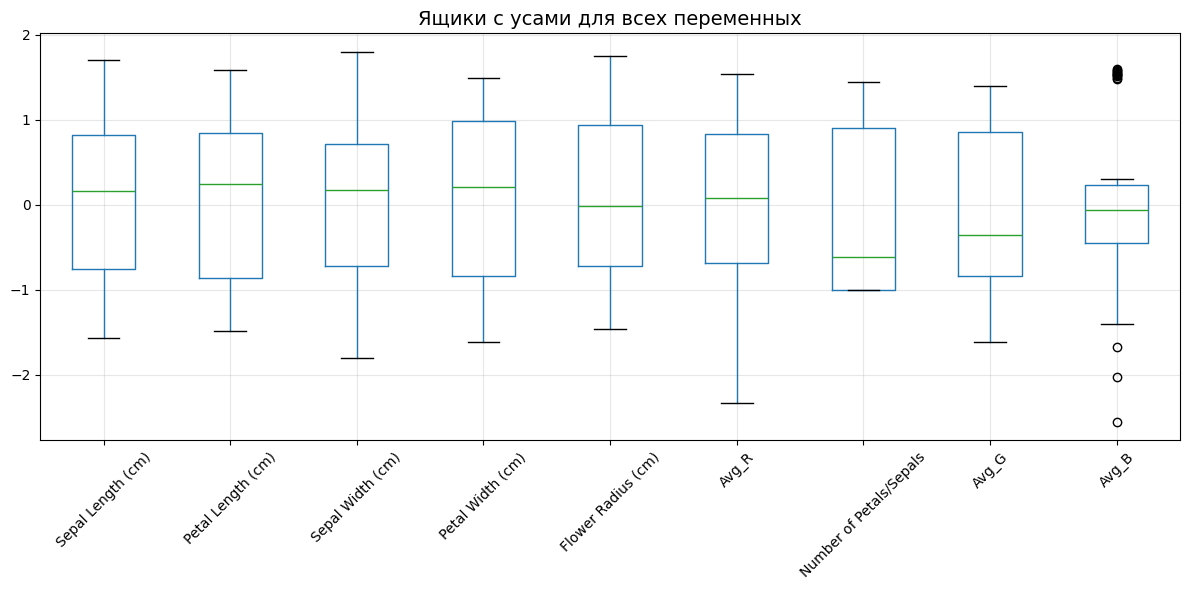

In [259]:
plt.figure(figsize=(12, 6))
scaled_df.boxplot()
plt.title('Ящики с усами для всех переменных', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Удаление ненужных признаков после анализа корреляции и ящиков с усами

In [260]:
drop_columns = ['Petal Width (cm)', 'Avg_B', 'Sepal Width (cm)', 'Avg_G', 'Flower Radius (cm)', 'Petal Length (cm)'] # Ненужные столбцы
scaled_df.drop(drop_columns, axis=1, errors='ignore', inplace=True) # Удаление столбцов


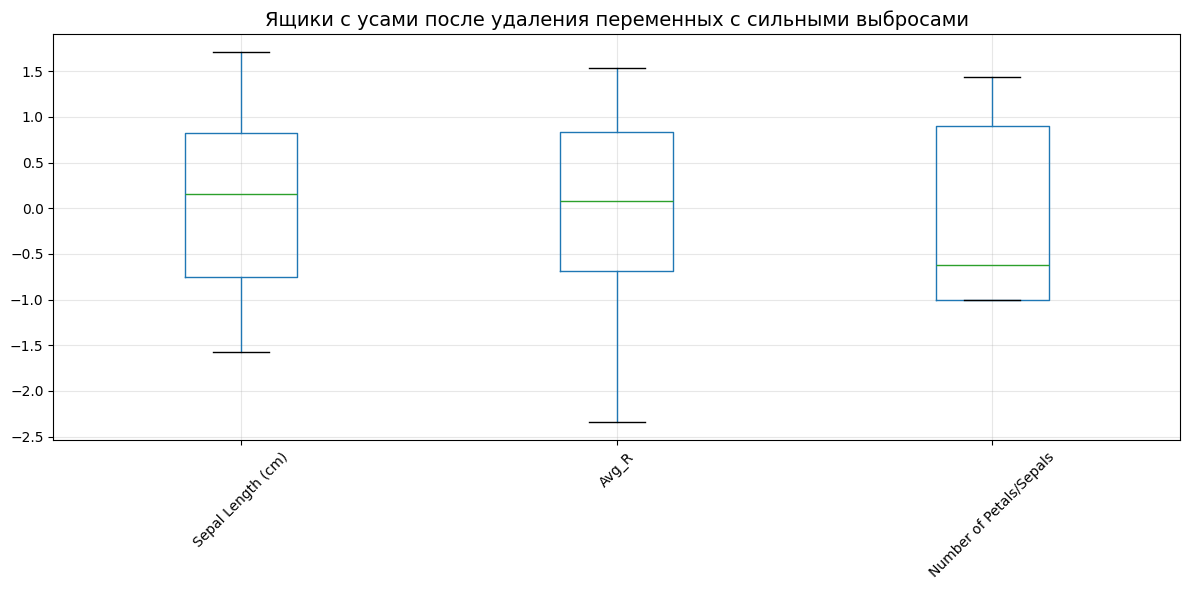

In [261]:
plt.figure(figsize=(12, 6))
scaled_df.boxplot()
plt.title('Ящики с усами после удаления переменных с сильными выбросами', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

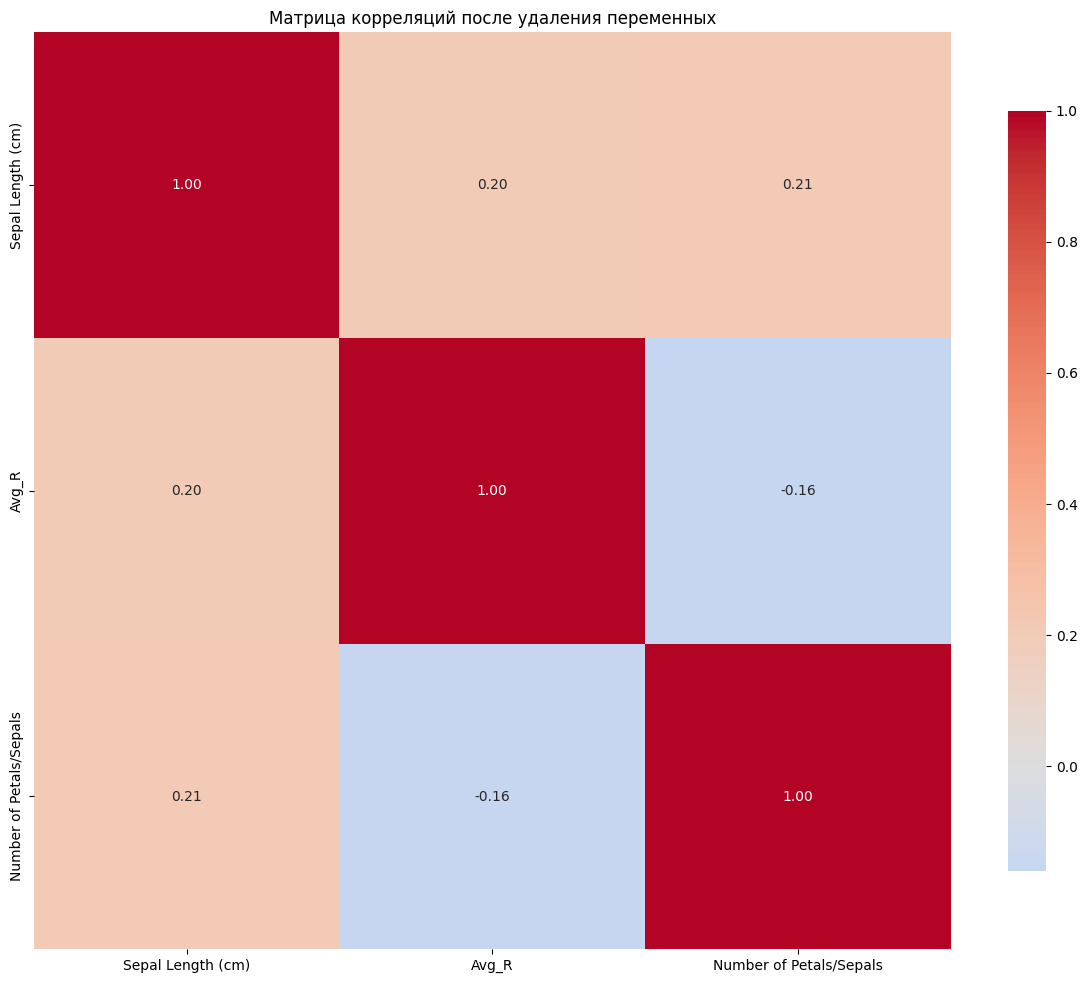

In [262]:
correlation_matrix = scaled_df.corr(method='pearson')

plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': .8})

plt.title('Матрица корреляций после удаления переменных')
plt.tight_layout()
plt.show()

#### После проведенных выше анализов и преобразований данных, получили набор переменных с минимальной корреляцией

## 5. Анализ матрицы диаграмм рассеяния

<Figure size 1200x1000 with 0 Axes>

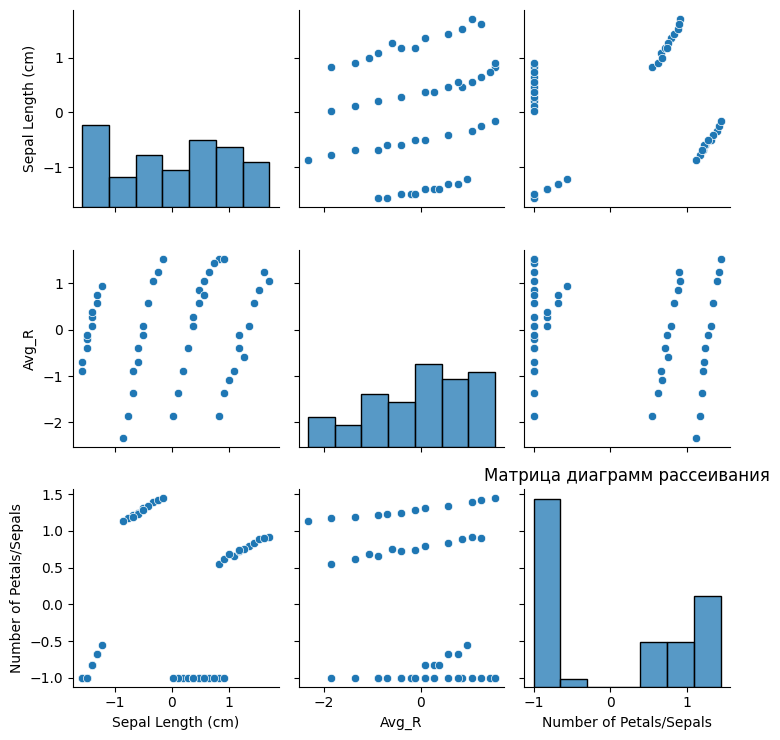

In [263]:
# Матрица диаграмм рассеивания
plt.figure(figsize=(12, 10))

sns.pairplot(scaled_df)

plt.title('Матрица диаграмм рассеивания')
plt.tight_layout()
plt.show()

#### По матрице диаграмм ресяния можно увидеть, что точки на осях разбиваются на вытянутые группы (то есть прямые из точек). Предварительно данные можно разделить на 3-4 группы. Размеры кластеров примерно одинаковые. 
Метод K-means более ориентирован на сферические кластеры, а метод DBSCAN на плотные. В нашем же случае кластеры небольшие и имеют вытянутую форму с не очень большой плотностью.

#### На основании анализа были выбраны следующие методы кластеризации:
- EM-алгоритм (Gaussian Mixture)
- Иерархическая кластеризация

## 5. Подбор оптимального K для метода Gaussian Mixture. Построение графика локтя и силуэта

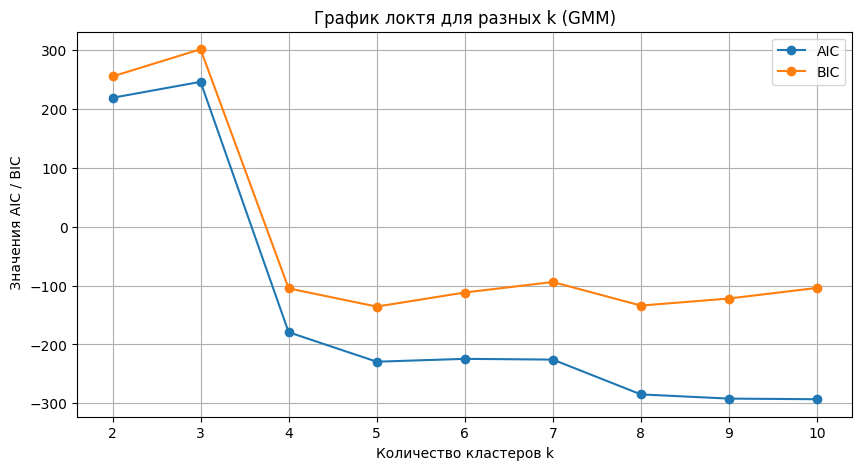

In [264]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

K = range(2, 11)
aic_scores = []
bic_scores = []

for k in K:
    gmm = GaussianMixture(n_components=k, random_state=43)
    gmm.fit(scaled_df)
    
    aic_scores.append(gmm.aic(scaled_df))
    bic_scores.append(gmm.bic(scaled_df))

# График AIC/BIC
plt.figure(figsize=(10,5))

plt.plot(K, aic_scores, '-o', label='AIC')
plt.plot(K, bic_scores, '-o', label='BIC')

plt.title('График локтя для разных k (GMM)')
plt.xlabel('Количество кластеров k')
plt.ylabel(' Значения AIC / BIC')
plt.xticks(K)
plt.grid(True)
plt.legend()
plt.show()


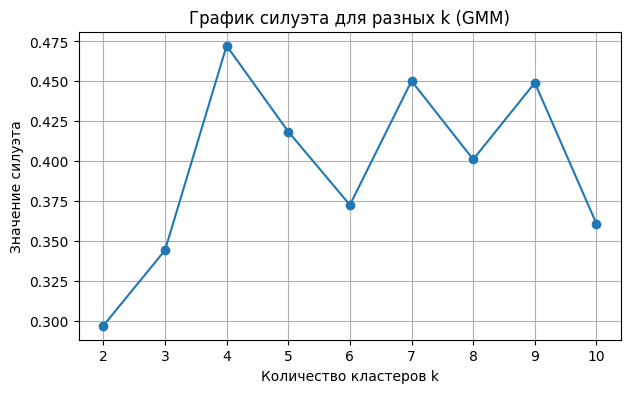

In [265]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

K = range(2, 11) 
sil_scores = []

for k in K:
    gmm = GaussianMixture(n_components=k, random_state=43)
    labels = gmm.fit_predict(scaled_df)
    sil = silhouette_score(scaled_df, labels)
    sil_scores.append(sil)


# График силуэта
plt.figure(figsize=(7,4))
plt.plot(K, sil_scores, '-o')

plt.title('График силуэта для разных k (GMM)')
plt.xlabel('Количество кластеров k')
plt.ylabel('Значение силуэта')
plt.grid(True)
plt.show()


#### По результатам графика локтя и графика силуэта для GMM, оптимальное количество кластеров K для метода GMM - 4

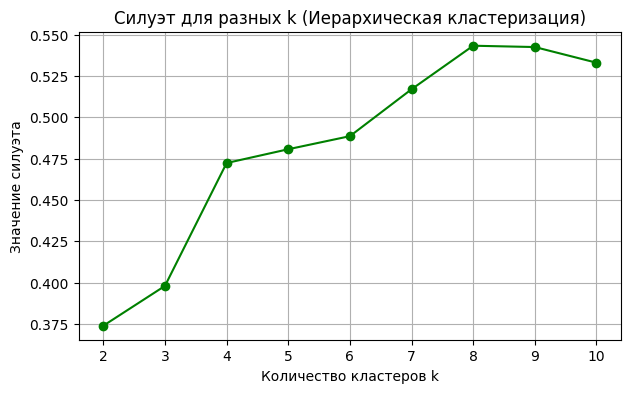

In [266]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

K = range(2, 11)
sil_scores = []

for k in K:
    hier = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hier.fit_predict(scaled_df)
    sil = silhouette_score(scaled_df, labels)
    sil_scores.append(sil)


plt.figure(figsize=(7,4))
plt.plot(K, sil_scores, '-o', color='green')
plt.title('Силуэт для разных k (Иерархическая кластеризация)')
plt.xlabel('Количество кластеров k')
plt.ylabel('Значение силуэта')
plt.grid(True)
plt.show()

#### По результатам графика силуэта для иерархической кластеризации оптимальное количество кластеров - 8

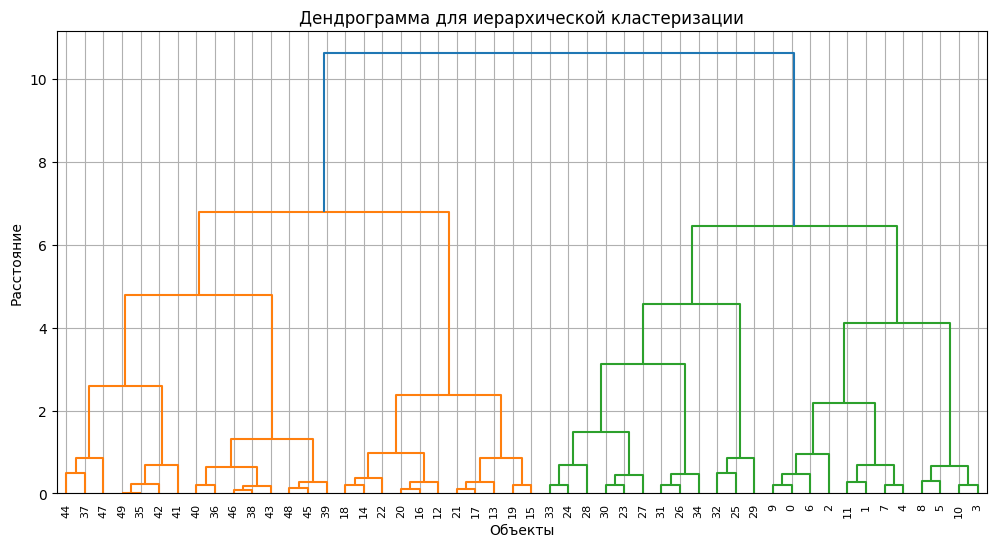

In [267]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


linked = linkage(scaled_df, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=False
)
plt.title("Дендрограмма для иерархической кластеризации")
plt.xlabel("Объекты")
plt.ylabel("Расстояние")
plt.grid(True)
plt.show()

На основе анализа дендрограммы можно сделать следующие выводы:

- Наибольший разрыв в вертикальном направлении происходит примерно на уровне 6–7.

- Левая часть дерева объединяет несколько объектов, которые слиты на низких уровнях - эти объекты очень похожи

- Правая часть дерева также содержит несколько подкластеров, которые объединяются постепенно - здесь тоже можно выделить внутренние группы

- Небольшие вертикальные внутри крупных ветвей говорят о том, что объекты внутри этих кластеров похожи друг на друга (малое расстояние слияния)

- Большие вертикальные скачки при объединении двух крупных ветвей говорят о существенном различии между кластерами

##### Дендрограмма говорит о том, что можно бможно рассмотреть выбрать подкластеры в пределах каждой основной ветви - примерно 4-5 кластеров

## 6. Кластеризация методом GMM и Иерархической кластеризации. Визуализация полученных кластеров

#### Gaussian mixture

In [268]:
gmm_clusters = GaussianMixture(n_components=4, random_state=43)
gmm_labels = gmm_clusters.fit_predict(scaled_df)

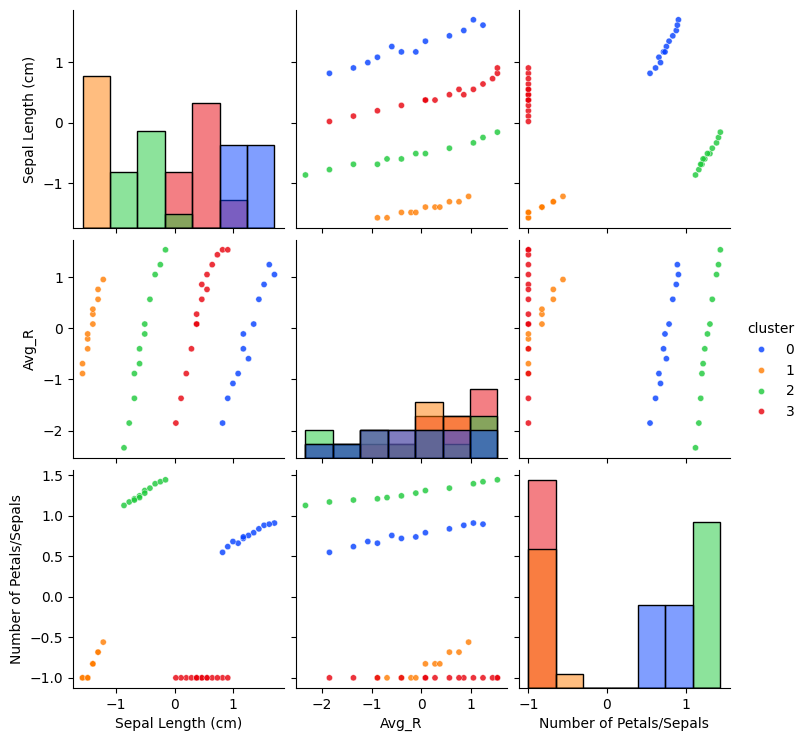

In [269]:
import seaborn as sns
import matplotlib.pyplot as plt

scaled_df_plot = scaled_df.copy()
scaled_df_plot['cluster'] = gmm_labels

sns.pairplot(scaled_df_plot, hue='cluster', diag_kind='hist', 
             plot_kws={'alpha':0.8, 's':20},
             palette='bright')
plt.show()

- По графикам рассеяния видно, что произошло четкое разбиение на кластеры в осях Sepal Length (cm) - Avg_R, Avg_R - Sepal Length (cm), Sepal Length (cm) - Number of Petals\Sepals. 
- В осях Avg_R - Number of Petals/Sepals, Number of Petals/Sepals - Avg_R имеется небольшое наложение кластеров 1 и 3.

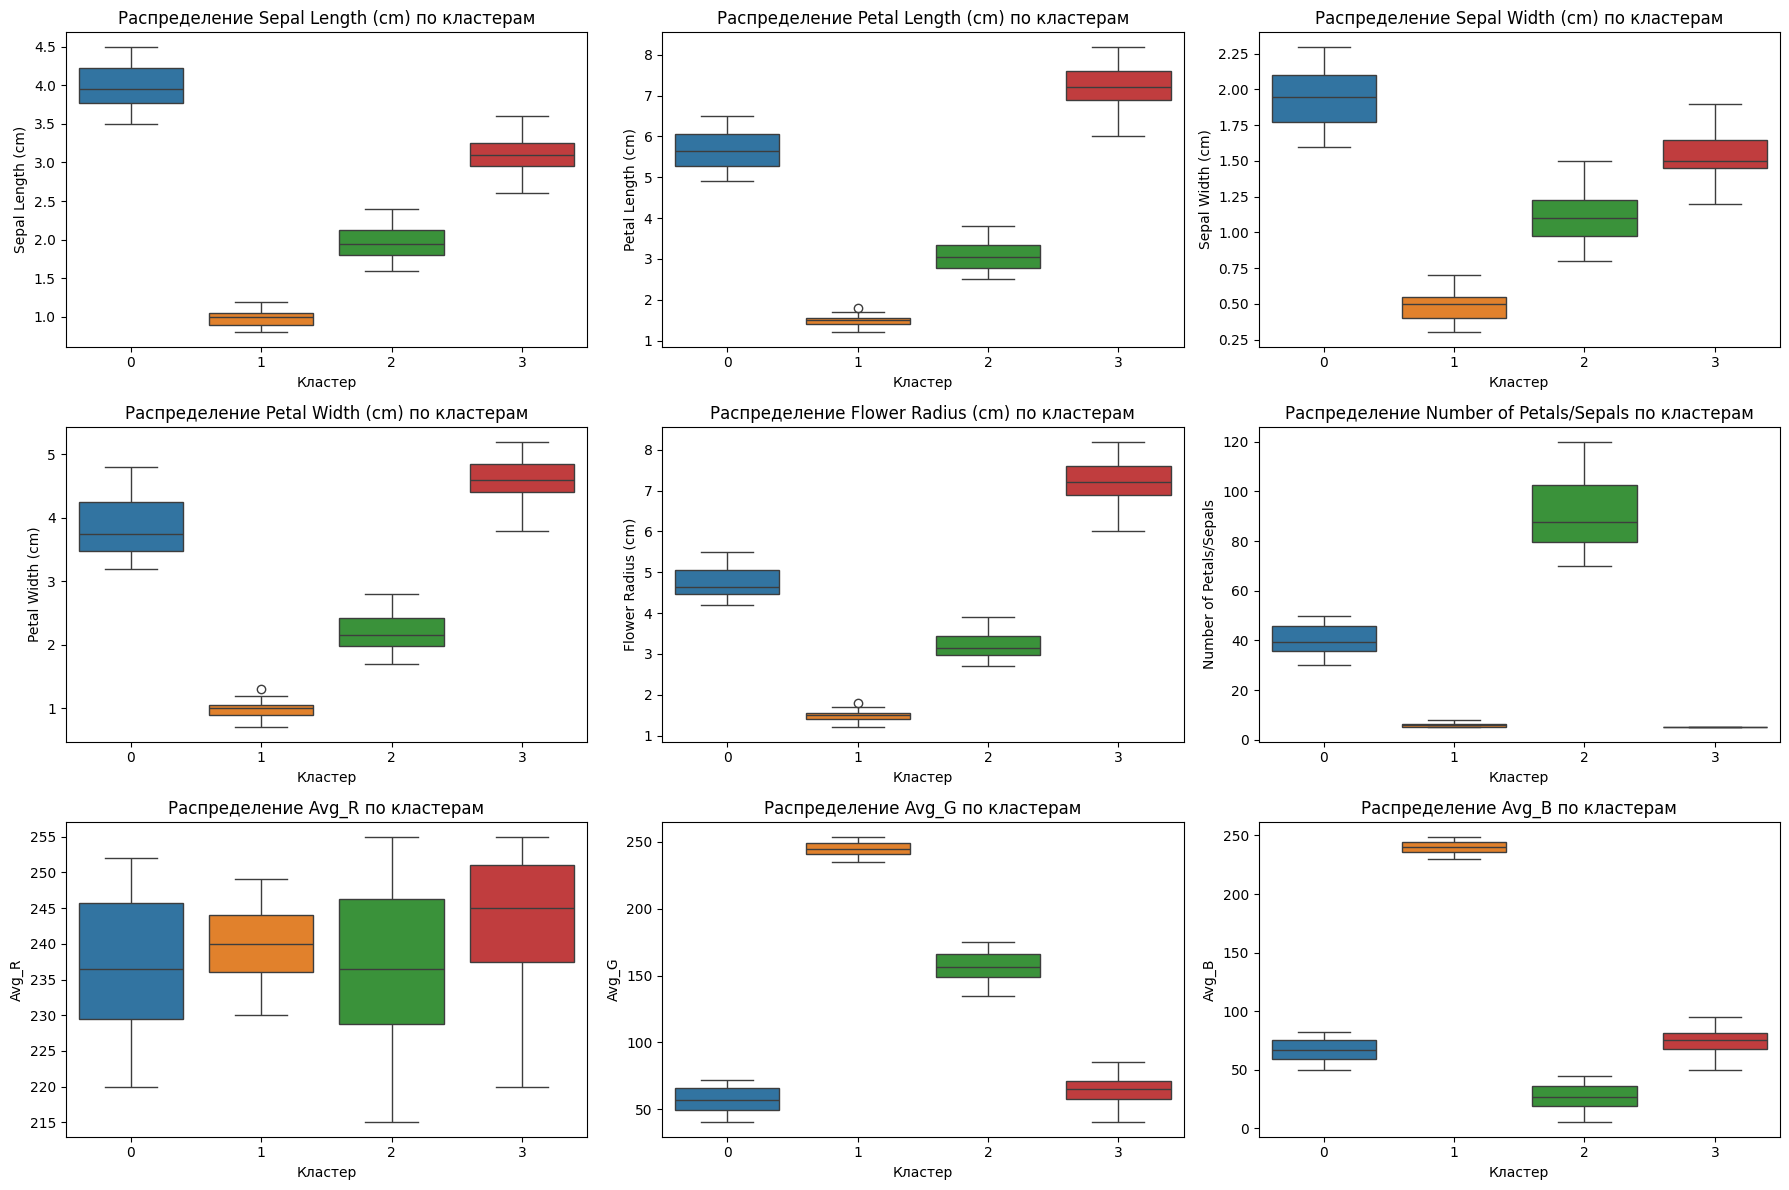

In [270]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df_plot = df.copy()
df_plot['Cluster'] = gmm_labels.astype(str)

num_cols = df_plot.select_dtypes(include=['number']).columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(
        data=df_plot,
        x='Cluster',
        y=col,
        hue='Cluster', 
        palette='tab10',
        legend=False      
    )
    plt.title(f'Распределение {col} по кластерам')
    plt.xlabel('Кластер')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


Расположение ящиков с усами также говорит о качестве кластеризации. В большинстве случаев ящики не накладываются друг на друга либо накладываются слабо.

Распределение Avg_R по кластером плохо

#### Иерархическая кластеризация

Метод локтя показал оптимальное количество кластеров для иерархической кластеризации 8, а дерево дендрограммы 4-5. Возьмем среднее значение k - 6.

In [271]:
hier_final = AgglomerativeClustering(n_clusters=6, linkage='ward')
hier_final_labels = hier_final.fit_predict(scaled_df)

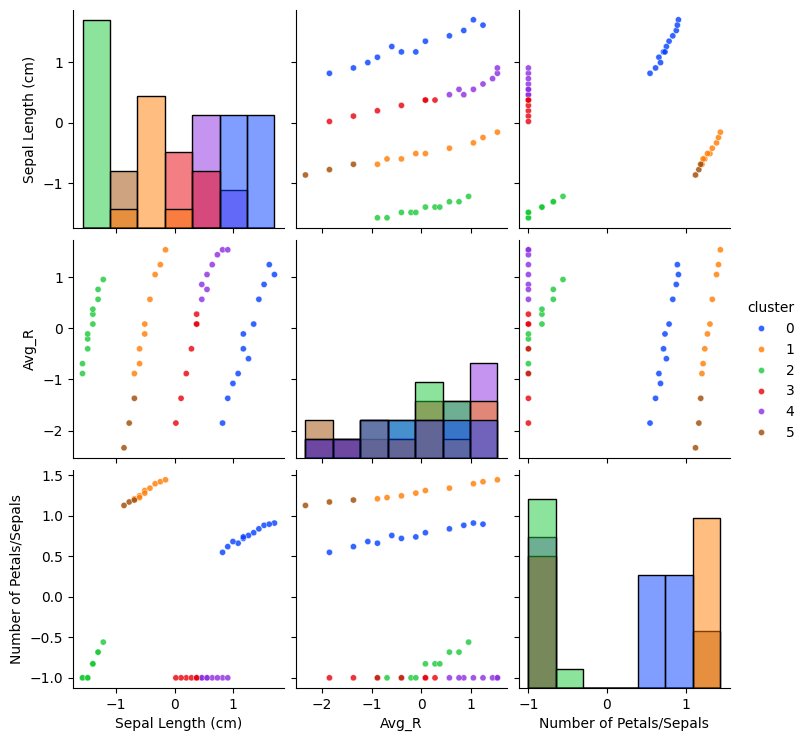

In [272]:
import seaborn as sns
import matplotlib.pyplot as plt

scaled_df_plot = scaled_df.copy()
scaled_df_plot['cluster'] = hier_final_labels

sns.pairplot(scaled_df_plot, hue='cluster', diag_kind='hist', 
             plot_kws={'alpha':0.8, 's':20},
             palette='bright')
plt.show()

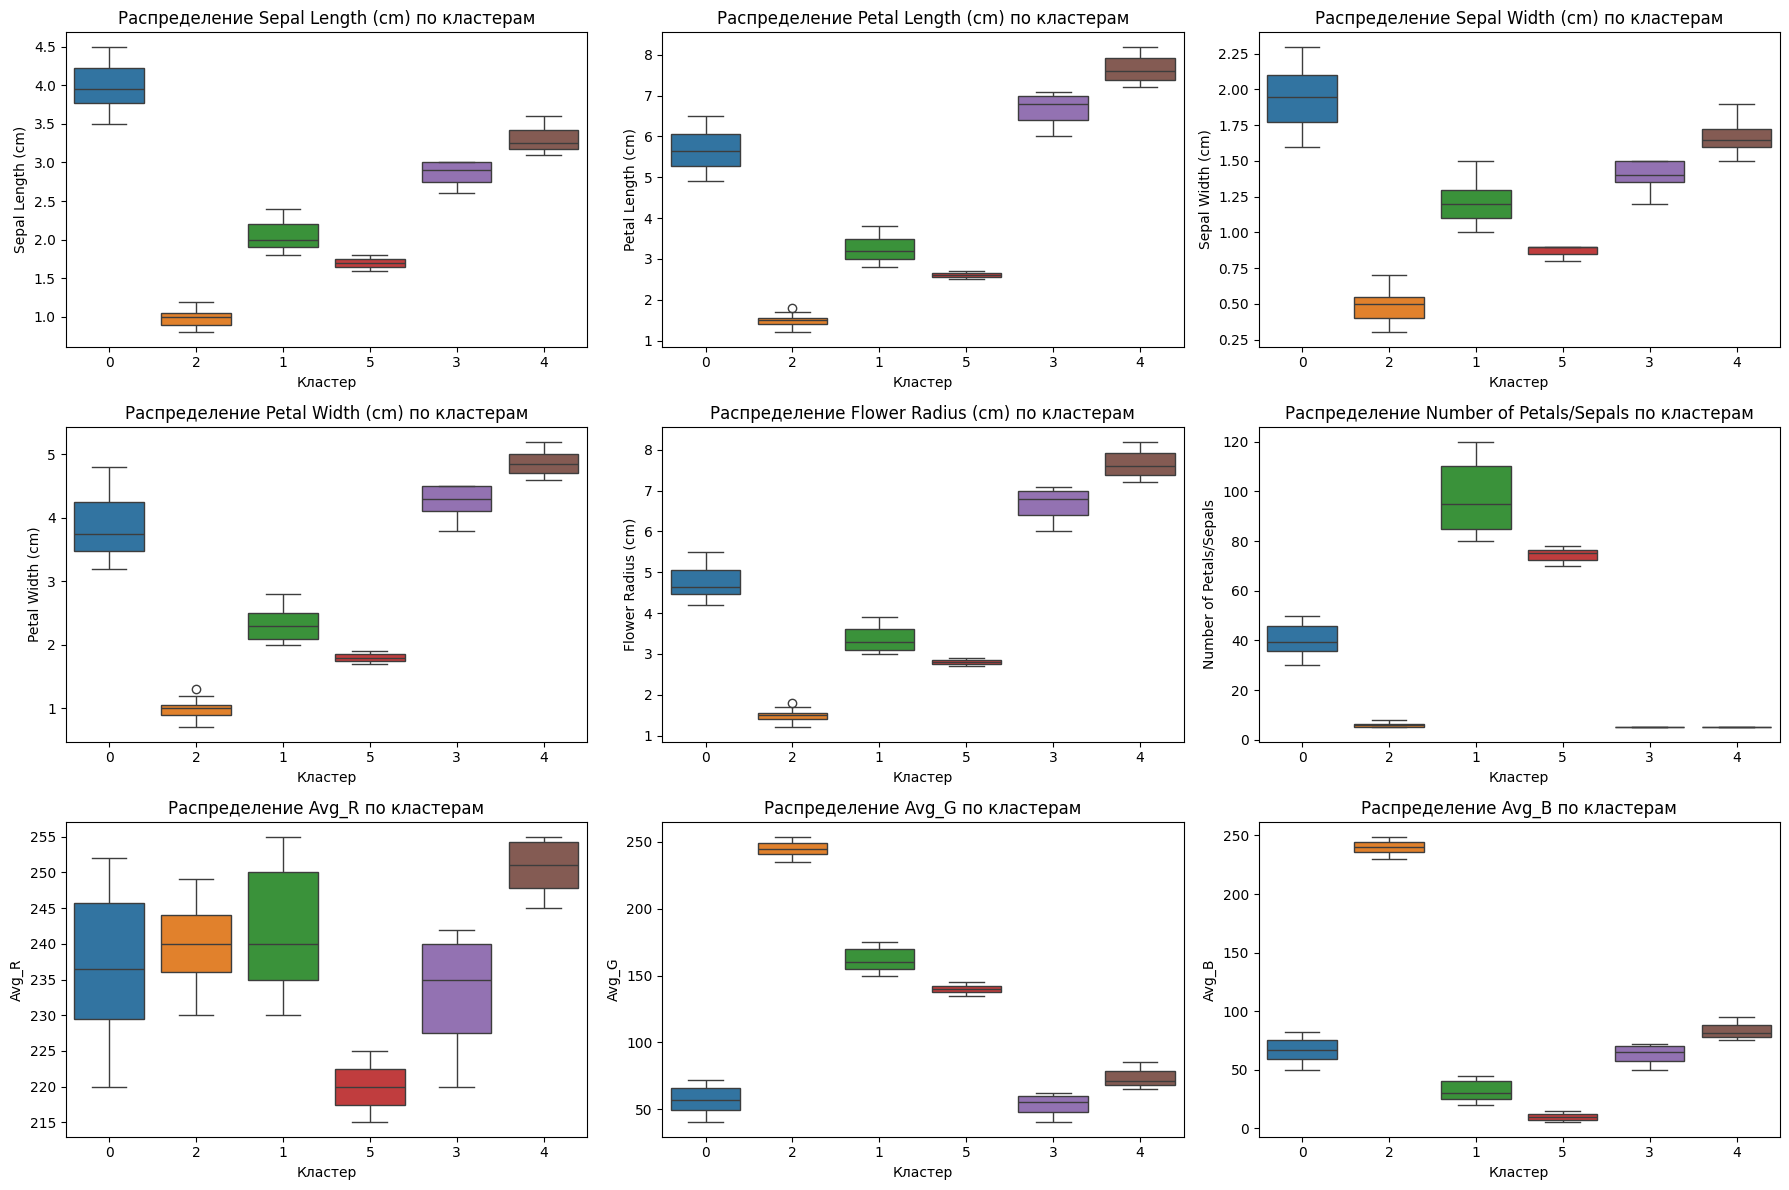

In [273]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df_plot = df.copy()
df_plot['Cluster'] = hier_final_labels.astype(str)

num_cols = df_plot.select_dtypes(include=['number']).columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(
        data=df_plot,
        x='Cluster',
        y=col,
        hue='Cluster', 
        palette='tab10',
        legend=False      
    )
    plt.title(f'Распределение {col} по кластерам')
    plt.xlabel('Кластер')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


#### Иерархическая кластеризация при k=6 показала более детальное разделение на кластеры. В среднем расположение кластеров относительно друг друга уменьшилось, перекрытие ящиков с усами в большинстве случаев все также минимально, однако такая подробная кластеризация вероятно избыточна, так как особого выйгрыша она не дала и остались все те же наложения кластеров, что были в методе GMM при 4 кластерах.

## 7. Метрики качества для методов кластеризации (GMM и иерархического)

#### Gaussian mixtures

In [274]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, jaccard_score

# Внутренние метрики для GMM
print("Silhouette:", silhouette_score(scaled_df, gmm_labels))
print("Calinski-Harabasz:", calinski_harabasz_score(scaled_df, gmm_labels))
print("Davies-Bouldin:", davies_bouldin_score(scaled_df, gmm_labels))

# Внешние метрики (если известны истинные классы y_true)
print("Adjusted Rand Index:", adjusted_rand_score(y_true, gmm_labels))
print("Fowlkes-Mallows Index:", fowlkes_mallows_score(y_true, gmm_labels))
# Jaccard можно посчитать по бинаризованным парам

Silhouette: 0.47232898626350867
Calinski-Harabasz: 30.77204216129424
Davies-Bouldin: 0.9021698194196958
Adjusted Rand Index: 1.0
Fowlkes-Mallows Index: 1.0


#### Иерархическая кластеризация

In [276]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, jaccard_score

# Внутренние метрики для GMM
print("Silhouette:", silhouette_score(scaled_df, hier_final_labels))
print("Calinski-Harabasz:", calinski_harabasz_score(scaled_df, hier_final_labels))
print("Davies-Bouldin:", davies_bouldin_score(scaled_df, hier_final_labels))

# Внешние метрики (если известны истинные классы y_true)
print("Adjusted Rand Index:", adjusted_rand_score(y_true, hier_final_labels))
print("Fowlkes-Mallows Index:", fowlkes_mallows_score(y_true, hier_final_labels))
# Jaccard можно посчитать по бинаризованным парам

Silhouette: 0.4885898309610186
Calinski-Harabasz: 38.245994015430135
Davies-Bouldin: 0.7104249837871618
Adjusted Rand Index: 0.7932043712334924
Fowlkes-Mallows Index: 0.8460221183027866


#### Анализ внутренних и венших метрик

| Метрика                    | GMM   | Иерархическая кластеризация |
| -------------------------- | ----- | --------------------------- |
| Silhouette                 | 0.472 | 0.489                       |
| Calinski-Harabasz          | 30.77 | 38.25                       |
| Davies-Bouldin             | 0.902 | 0.710                       |
| Adjusted Rand Index (ARI)  | 1.0   | 0.793                       |
| Fowlkes-Mallows Index (FM) | 1.0   | 0.846                       |


Иерархическая кластеризация показывает лучшие показатели по компактности и разделению кластеров: Silhouette выше, Davies-Bouldin ниже, Calinski-Harabasz выше, что означает, что кластеры более однородны и лучше отделены друг от друга в признаковом пространстве.

Внешние метрики (Adjusted Rand Index, Fowlkes-Mallows Index): GMM демонстрирует идеальное соответствие с истинными классами (ARI = 1.0, FM = 1.0), иерархическая кластеризация показывает меньшую согласованность с истинными классами (ARI = 0.79, FM = 0.85), что указывает на частичное несовпадение кластеров с эталонными метками.

Методы оптимизируют разные критерии: GMM учитывает вероятностное распределение данных и хорошо моделирует реальные классы, а иерархическая кластеризация формирует более логичные кластеры по расстоянию, хоть они и не всегда совпадают с эталонными классами.

In [275]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Загружаем коэффициенты PCA
# loadings = pd.DataFrame(
#     pca.components_.T,
#     columns=['PC1', 'PC2'],
#     index=scaled_df.columns
# )

# plt.figure(figsize=(8, 6))
# sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
# plt.title('Вклад переменных в PCA компоненты')
# plt.show()